# Finding Cycles (with NetworkX)

pynucastro uses [NetworkX](https://networkx.org) internally for the main network plots.  The
graph-representation of a network can be exported so any NetworkX methods can be used on
the network.

Here's an example of finding cycles in a network.

In [1]:
import pynucastro as pyna
import networkx as nx

## A simple CNO / hot-CNO network

We'll create a reaction network that includes CNO, hot-CNO, and some breakout

In [2]:
nuclei = ["p", "he4",
          "c12", "c13",
          "n13", "n14", "n15",
          "o14", "o15", "o16",
          "f17", "f18"]

In [3]:
rl = pyna.ReacLibLibrary()

In [4]:
lib = rl.linking_nuclei(nuclei, with_reverse=False)

In [5]:
rc = pyna.RateCollection(libraries=lib)

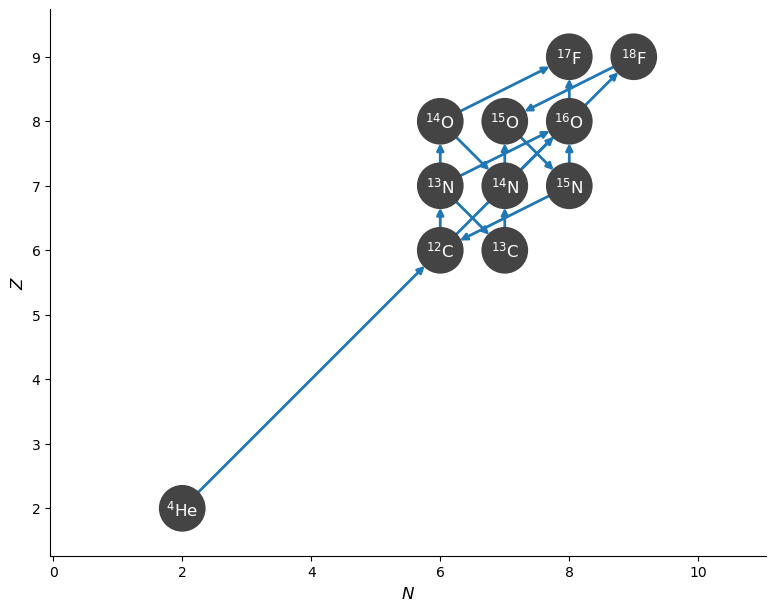

In [6]:
fig = rc.plot()

## Finding all cycles

Now we can use the {py:func}`create_network_graph <pynucastro.networks.rate_collection.RateCollection.create_network_graph>` function to export a NetworkX graph object.  This function can take many of the same filtering options as `plot()`, which is useful for removing links that you don't want NetworkX to consider.

In [7]:
G = rc.create_network_graph(rc.unique_nuclei)

In [8]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

Now we'll use the [simple_cycles](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cycles.simple_cycles.html) algorithm to find the cycles.

In [9]:
cycles = nx.simple_cycles(G)
for n, c in enumerate(cycles):
    print(n, c)

0 [C12, N13, C13, N14, O15, N15]
1 [C12, N13, C13, N14, F18, O15, N15]
2 [C12, N13, O14, N14, O15, N15]
3 [C12, N13, O14, N14, F18, O15, N15]


Cycle 0 is the traditional CNO cycle and cycle 2 is the hot-CNO cycle.

Of course, which cycles are actually active depends on the values of the rates linking the nuclei, and therefore the thermodynamic state.  We can look at this.

## Using thermodynamic info to constrain cycles

Let's pick a thermodynamic state this is not hot enough to expect breakout from hot-CNO

In [10]:
rho = 1.e4
T = 5.e7
comp = pyna.Composition(rc.unique_nuclei, init="solar")

In [11]:
rates = rc.evaluate_rates(rho=rho, T=T, composition=comp)
rates

{N13 ⟶ C13 + e⁺ + 𝜈: np.float64(8.916255821408856e-21),
 O14 ⟶ N14 + e⁺ + 𝜈: np.float64(1.663612053803672e-09),
 O15 ⟶ N15 + e⁺ + 𝜈: np.float64(3.7877045306680386e-20),
 C12 + p ⟶ N13 + 𝛾: np.float64(3.595829193684256e-08),
 C12 + He4 ⟶ O16 + 𝛾: np.float64(7.456484402367769e-29),
 C13 + p ⟶ N14 + 𝛾: np.float64(1.2282426904398937e-09),
 N13 + p ⟶ O14 + 𝛾: np.float64(5.0141149002007184e-23),
 N14 + p ⟶ O15 + 𝛾: np.float64(1.0892337347080713e-10),
 N14 + He4 ⟶ F18 + 𝛾: np.float64(1.225648423161127e-34),
 N15 + p ⟶ O16 + 𝛾: np.float64(2.684431828132115e-22),
 O16 + p ⟶ F17 + 𝛾: np.float64(7.795144464790595e-11),
 N13 + He4 ⟶ p + O16: np.float64(5.720265979368537e-39),
 N15 + p ⟶ He4 + C12: np.float64(6.552964976637405e-19),
 O14 + He4 ⟶ p + F17: np.float64(1.1771735714754966e-34),
 F18 + p ⟶ He4 + O15: np.float64(1.0396665715602209e-07),
 3 He4 ⟶ C12 + 𝛾: np.float64(3.129277512975574e-33)}

### Cutting by branching

Wwe can instead look at each nucleus and consider all the rates that consume it.  We can filter out any rates that are below a threshold compared to the maximum rate consuming that nucleus.  This is done via `consuming_rate_threshold`.

First let's visualize this.

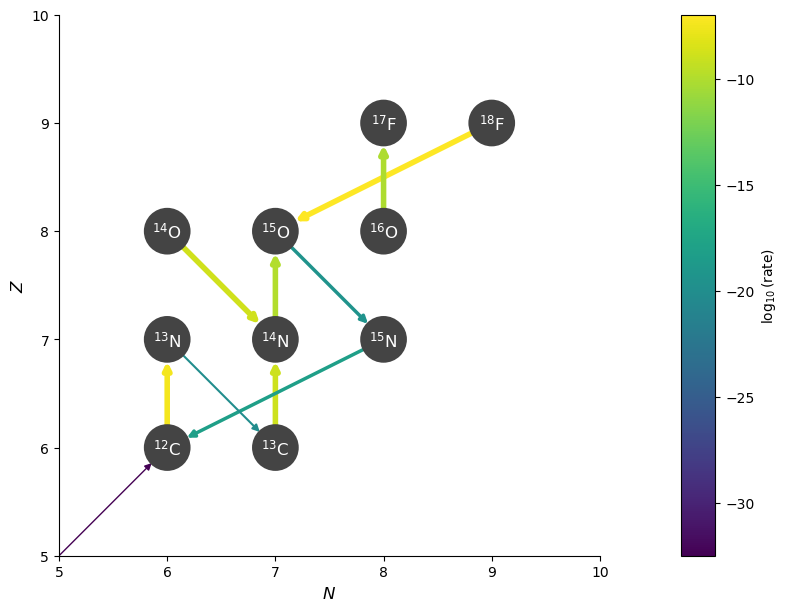

In [12]:
fig = rc.plot(rho=rho, T=T, comp=comp,
              consuming_rate_threshold=0.1,
              N_range=(5,10), Z_range=(5,10))

In [13]:
fig.set_size_inches(6, 5)
fig.savefig("cno_branching.pdf", bbox_inches="tight")

We see that this has filtered out the proton capture on ${}^{13}\mathrm{N}$, removing the hot-CNO cycle.

Now let's recreate the network graph using this filtering.

In [14]:
G = rc.create_network_graph(rc.unique_nuclei,
                            rate_ydots=rates, consuming_rate_threshold=0.1)

In [15]:
cycles = nx.simple_cycles(G)
for n, c in enumerate(cycles):
    print(n, c)

0 [C12, N13, C13, N14, O15, N15]


Now, as expected, only a single cycle is really dominate under these conditions --- the CNO cycle.

What happens if we make it hotter?

In [16]:
T = 5.e8
rates = rc.evaluate_rates(rho=rho, T=T, composition=comp)

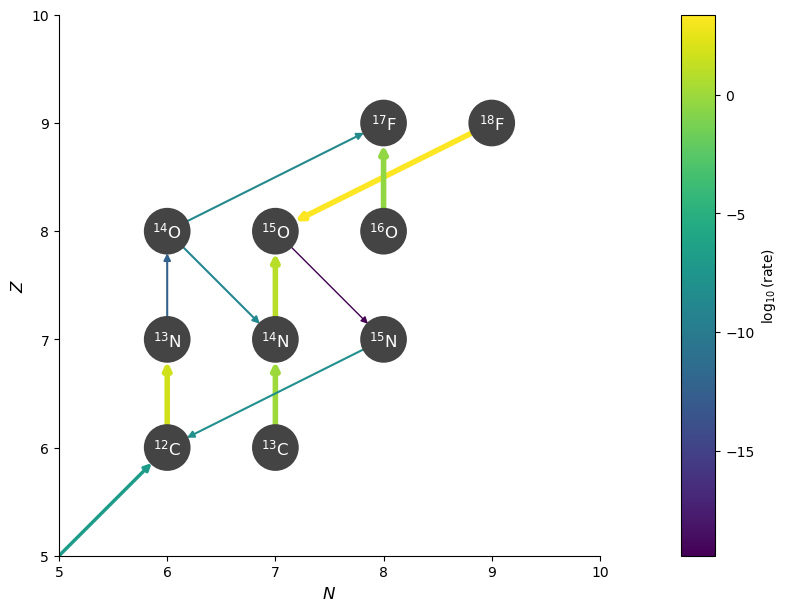

In [17]:
fig = rc.plot(rho=rho, T=T, comp=comp,
              consuming_rate_threshold=0.1,
              N_range=(5,10), Z_range=(5,10))

In [18]:
fig.set_size_inches(6, 5)
fig.savefig("hotcno_branching.pdf", bbox_inches="tight")

In [19]:
G = rc.create_network_graph(rc.unique_nuclei,
                            rate_ydots=rates, consuming_rate_threshold=0.1)

In [20]:
cycles = nx.simple_cycles(G)
for n, c in enumerate(cycles):
    print(n, c)

0 [C12, N13, O14, N14, O15, N15]


Now we see that the hot-CNO cycle is the one that dominates!